# Colorizer

Paper: Colorful Image Colorization by Richard Zhang, Phillip Isola, Alexei A. Efros (https://arxiv.org/pdf/1603.08511)

This notebook implements a deep-learning image colorization pipeline based on the referenced paper.

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132
!{sys.executable} -m pip install scikit-image tqdm matplotlib kornia

Looking in indexes: https://download.pytorch.org/whl/cu132



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
import kornia
import skimage
import numpy as np
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch import Tensor
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

In [4]:
PICTURE_SIZE = 256

PREPROCESSING_BATCH_SIZE = 32

TRAINING_EPOCHS = 20
TRAINING_BATCH_SIZE = 32

OUT_DIR = "out"
DATASET_DIR = "data"

In [5]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

Using device: cuda


## Centroids

First we have to generate a set of quantized a-b color centroids that are inside the RGB gamut.

We'll sample a grid in a-b space, convert to RGB and back to Lab to filter out-of-gamut values, then normalize to [0,1].

These centroids provide a discrete color palette the model will predict per pixel, simplifying output representation.

Generated 141 in-gamut centroids.
Centroid shape: (141, 2)
Sample centroids (a, b):
[[0.578125  0.2265625]
 [0.6171875 0.2265625]
 [0.65625   0.2265625]
 [0.6953125 0.2265625]
 [0.734375  0.2265625]]


C:\Users\ricca\AppData\Local\Temp\ipykernel_364964\4029481786.py:18: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 25 negative Z values that have been clipped to zero
  rgb_pixels = skimage.color.lab2rgb(lab_pixels)


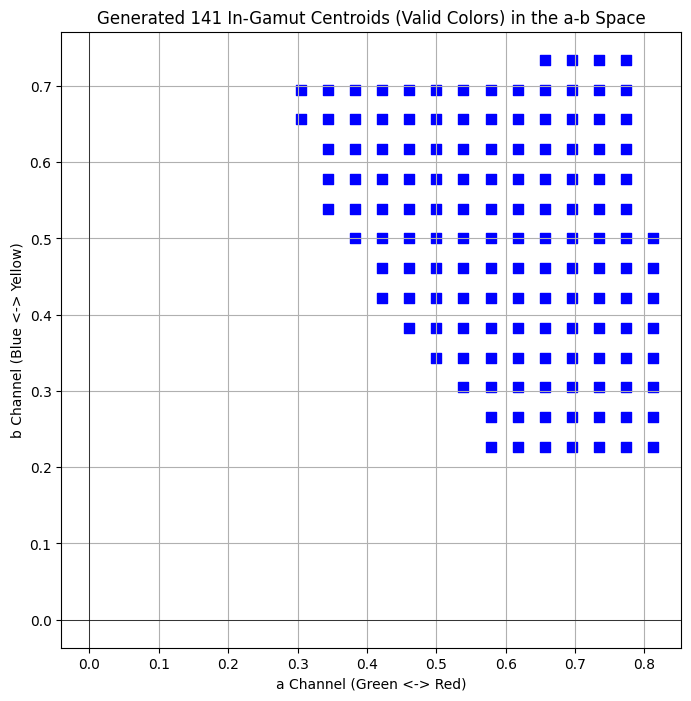

In [6]:
def generate_ab_centroids(step=10):
    """
    Generate the centroids of the quantized a-b color space that are within the RGB gamut.
    """

    # Create a full 2D grid of a and b values
    a_vals = np.arange(-120, 130, step)
    b_vals = np.arange(-120, 130, step)
    a_grid, b_grid = np.meshgrid(a_vals, b_vals)

    # Build a "fake" image matrix (Height x Width x Channels)
    lab_pixels = np.zeros((a_grid.shape[0], a_grid.shape[1], 3))
    lab_pixels[:, :, 0] = 50.0  # L channel
    lab_pixels[:, :, 1] = a_grid
    lab_pixels[:, :, 2] = b_grid

    # Convert to RGB (skimage clips out-of-gamut values to [0, 1] here)
    rgb_pixels = skimage.color.lab2rgb(lab_pixels)

    # Convert back to Lab to see if the colors survived the conversion
    lab_reconstructed = skimage.color.rgb2lab(rgb_pixels)

    # Calculate the Euclidean distance (Delta E) between original and reconstructed
    delta = np.linalg.norm(lab_pixels - lab_reconstructed, axis=-1)

    # If the delta is large, the color was clipped (out of gamut).
    # We use < 1.0 to allow for tiny floating-point rounding errors.
    valid_mask = delta < 1.0

    # Extract the valid a and b coordinates based on the mask
    valid_a = a_grid[valid_mask]
    valid_b = b_grid[valid_mask]

    # Combine them into the final (N, 2) array
    result = np.column_stack((valid_a, valid_b))

    # Normalize to [0.0, 1.0] range for easier use in training
    result = (result + 128.0) / 256.0

    return result


centroids = generate_ab_centroids()
centroids_count = len(centroids)
print(f"Generated {centroids_count} in-gamut centroids.")
print(f"Centroid shape: {centroids.shape}")
print("Sample centroids (a, b):")
print(centroids[:5])  # Print the first 5 centroids as a sample

plt.figure(figsize=(8, 8))
plt.scatter(centroids[:, 0], centroids[:, 1], c="blue", marker="s", s=50)
plt.title(
    f"Generated {centroids_count} In-Gamut Centroids (Valid Colors) in the a-b Space"
)
plt.xlabel("a Channel (Green <-> Red)")
plt.ylabel("b Channel (Blue <-> Yellow)")
plt.grid(True)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.show()

## Dataset preprocessing

We'll convert images to LAB, extract the L channel and map each pixel's a-b coordinates to the nearest centroid, saving the L tensor and target indices to disk for fast training.

For this task we'll use Kornia for fast GPU LAB conversions and torch.cdist to compute nearest centroids; the results will be saved as .pt files.

Precomputing targets avoids repeating expensive color conversions during training and keeps the training loop simple.

In [7]:
class IndexedImagenette(torchvision.datasets.Imagenette):
    """
    Wrapper around torchvision's Imagenette dataset to also return the index of each image, which is useful for caching precomputed results.
    """

    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        return img, target, index


def precompute_dataset(batch_size: int, ab_bins_tensor: Tensor, split="train"):
    save_dir = os.path.join(OUT_DIR, "precomputed_imagenette", split)
    os.makedirs(save_dir, exist_ok=True)

    # Transformation pipeline: ToTensor() converts the image to [C, H, W] in the range [0.0, 1.0]
    transform = torchvision.transforms.Compose(
        [
            torchvision.transforms.Resize((PICTURE_SIZE, PICTURE_SIZE)),
            torchvision.transforms.ToTensor(),
        ]
    )

    base_dataset = IndexedImagenette(
        root=DATASET_DIR,
        split=split,
        download=True,
        transform=transform,
    )

    # Pre-filtering: find only the indices of images that haven't been computed yet
    unprocessed_indices = [
        idx
        for idx in range(len(base_dataset))
        if not os.path.exists(os.path.join(save_dir, f"img_{idx}.pt"))
    ]

    if not unprocessed_indices:
        print(f"All images for the '{split}' set have already been computed!")
        return

    # DataLoader to load images in parallel batches
    subset = Subset(base_dataset, unprocessed_indices)
    dataloader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    print(
        f"Starting pre-computation for the {split} set: {len(unprocessed_indices)} images remaining out of {len(base_dataset)}"
    )

    # Disabling gradients to speed up and save VRAM
    with torch.no_grad():
        for imgs, _, indices in tqdm(dataloader):
            imgs = imgs.to(device)

            # Convert from RGB to LAB entirely on GPU using Kornia
            # Returns a LAB tensor where L is in [0, 100] and a,b are in [-128, 128]
            lab_batch = kornia.color.rgb_to_lab(imgs)

            # Extract and normalize L to [0.0, 1.0]
            L = lab_batch[:, 0:1, :, :]  # Shape: (B, 1, H, W)
            L_norm = L / 100.0

            # Extract ab, normalize to [0.0, 1.0], and find nearest centroids
            ab = lab_batch[:, 1:3, :, :]  # Shape: (B, 2, H, W)
            ab = (ab + 128.0) / 256.0  # Normalize a and b to [0.0, 1.0]
            B, C, H, W = ab.shape

            # Flatten 'ab' to calculate distances for all pixels in the batch at once
            ab_flat = ab.permute(0, 2, 3, 1).reshape(B * H * W, 2)

            distances = torch.cdist(ab_flat, ab_bins_tensor)
            nearest_bins = torch.argmin(distances, dim=1)
            target_batch = nearest_bins.view(B, H, W).long()  # Returns a (B, H, W)

            # Move the results to CPU for saving
            L_norm_cpu = L_norm.cpu()
            target_batch_cpu = target_batch.cpu()

            # Save the results for each image in the batch
            for i in range(B):
                idx = indices[i].item()
                save_path = os.path.join(save_dir, f"img_{idx}.pt")
                torch.save((L_norm_cpu[i], target_batch_cpu[i]), save_path)


precompute_dataset(
    batch_size=PREPROCESSING_BATCH_SIZE,
    split="train",
    ab_bins_tensor=torch.tensor(centroids, dtype=torch.float32, device=device),
)

All images for the 'train' set have already been computed!


In [8]:
class PrecomputedColorizationDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir):
        """
        Loads the precomputed tensors directly from the .pt files saved previously.
        """
        self.data_dir = data_dir
        self.files = [f for f in os.listdir(data_dir) if f.endswith(".pt")]

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .pt files found in {data_dir}. Did you run the precompute script?"
            )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.files[idx])
        L_tensor, target_tensor = torch.load(file_path)
        return L_tensor, target_tensor

## Training

We have to define a convolutional neural network that takes the L channel and predicts a per-pixel distribution over centroids,
then train it with a class-weighted cross-entropy loss to encourage diverse color predictions.

We'll compute class frequencies from precomputed targets to build weights, use Adam optimizer with paper-recommended hyperparameters,
and periodically save model checkpoints.

Weighted loss reduces bias toward common colors and helps the network predict less frequent but plausible colors.

In [9]:
class ColorfulImageColorizationNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv1: 2 layers, spatial downsampling at the last layer, followed by BatchNorm
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),  # Downsampling
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
        )

        # Conv2: 2 layers, spatial downsampling at the last layer
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),  # Downsampling
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
        )

        # Conv3: 3 layers, spatial downsampling at the last layer
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),  # Downsampling
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
        )

        # Conv4: 3 layers, no downsampling
        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
        )

        # Conv5: 3 layers with dilated convolutions (à trous) with dilation=2
        self.conv5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
        )

        # Conv6: 3 layers with dilated convolutions (à trous) with dilation=2
        self.conv6 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
        )

        # Conv7: 3 layers, no downsampling
        self.conv7 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
        )

        # Conv8: spatial upsampling at the beginning of the block
        self.conv8 = nn.Sequential(
            nn.ConvTranspose2d(
                256, 128, kernel_size=4, stride=2, padding=1
            ),  # Upsampling
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
        )

        # Final layer: maps the feature map to centroids_count quantized values
        self.conv_out = nn.Conv2d(
            128, centroids_count, kernel_size=1, stride=1, padding=0
        )

        # Bilinear upsampling to restore the output to the original size (e.g., 256x256)
        self.upsample = nn.Upsample(
            scale_factor=4, mode="bilinear", align_corners=False
        )

    def forward(self, x):
        # x is the lightness channel L
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        x = self.conv8(x)

        # Logits of the probability distribution over the centroids_count colors
        x = self.conv_out(x)

        # Final upsampling implemented as a feed-forward layer
        x = self.upsample(x)

        return x

In [10]:
def calculate_weights_tensor() -> Tensor:
    train_dataset = PrecomputedColorizationDataset(
        data_dir=os.path.join(OUT_DIR, "precomputed_imagenette", "train")
    )

    # Calculate the frequency of each bin in the training dataset
    bin_counts = np.zeros(centroids_count, dtype=np.float64)

    for L_tensor, target_tensor in train_dataset:
        # target_tensor has shape (H, W) with integer indices of the bins
        flat = target_tensor.numpy().flatten()
        counts = np.bincount(flat, minlength=centroids_count)
        bin_counts += counts

    # Frequency of each bin
    bin_freq = bin_counts / bin_counts.sum()

    # Weights inversely proportional to frequency, with smoothing to avoid division by zero
    # w(q) = 1 / ((1 - lambda) * p(q) + lambda / Q)
    lam = 0.5
    Q = centroids_count
    weights = 1.0 / ((1 - lam) * bin_freq + lam / Q)

    # Normalize the weights so that their mean is 1 (to not alter the scale of the loss)
    weights = weights / weights.mean()

    return torch.tensor(weights, dtype=torch.float32).to(device)


weights_tensor = calculate_weights_tensor()

print("Calculated weights tensor for the loss function:")
print(weights_tensor)

Calculated weights tensor for the loss function:
tensor([1.2413, 1.2222, 1.2059, 1.2448, 1.2516, 1.2706, 1.2536, 1.0816, 1.1950,
        1.2466, 1.2682, 1.2721, 1.2723, 1.2721, 0.7970, 1.0631, 1.1930, 1.2558,
        1.2707, 1.2723, 1.2721, 1.2721, 0.5469, 0.7025, 1.0772, 1.2323, 1.2547,
        1.2682, 1.2703, 1.2718, 1.2719, 0.7685, 0.3803, 0.7504, 1.1413, 1.2324,
        1.2631, 1.2689, 1.2701, 1.2705, 1.2710, 1.0690, 0.6019, 0.2762, 0.7108,
        1.1796, 1.2426, 1.2577, 1.2639, 1.2678, 1.2677, 1.2696, 1.0584, 0.4772,
        0.1091, 0.5812, 1.1209, 1.2142, 1.2338, 1.2573, 1.2660, 1.2697, 1.2695,
        1.1501, 0.9675, 0.2959, 0.0250, 0.3228, 0.9271, 1.1544, 1.2159, 1.2427,
        1.2613, 1.2696, 1.2711, 1.2178, 1.1100, 0.7724, 0.2595, 0.0861, 0.2325,
        0.6320, 0.9939, 1.1585, 1.2182, 1.2422, 1.2667, 1.1980, 1.0135, 0.5475,
        0.3285, 0.2233, 0.3025, 0.5961, 0.8763, 1.0438, 1.1583, 1.2178, 1.2604,
        1.1356, 0.8368, 0.4973, 0.4698, 0.4720, 0.4961, 0.7037, 0.9211,

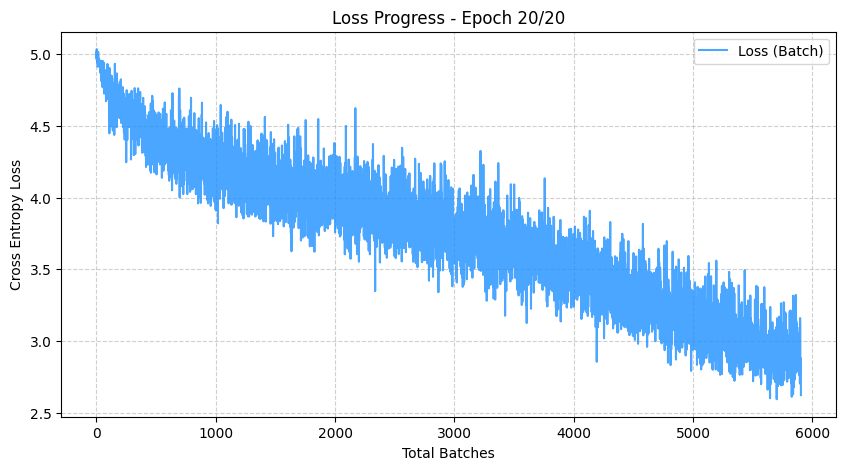

Epoch [20/20]: 100%|██████████| 296/296 [03:11<00:00,  1.55it/s, loss=2.63]

Training completed!


In [16]:
def train_model(epochs: int, batch_size: int, continue_from_last_checkpoint=True):
    save_dir = os.path.join(OUT_DIR, "model")
    os.makedirs(save_dir, exist_ok=True)

    # Deallocation of GPU memory before starting training to avoid fragmentation issues
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Inizializza modello e dataset
    model = ColorfulImageColorizationNet().to(device)
    train_dataset = PrecomputedColorizationDataset(
        data_dir=os.path.join(OUT_DIR, "precomputed_imagenette", "train")
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )

    # Loss function: Cross Entropy Multinomiale [cite: 173]
    # nn.CrossEntropyLoss in PyTorch calcola in automatico la Softmax internamente.
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    # Optimizer: the paper uses ADAM [cite: 236].
    # Paper-specific parameters: lr=3e-5, beta1=0.9, beta2=0.99, weight_decay=1e-3 [cite: 238].
    optimizer = torch.optim.Adam(
        model.parameters(), lr=3e-5, betas=(0.9, 0.99), weight_decay=1e-3
    )

    # Setup loss chart
    plt.ion()  # Enables interactive mode in matplotlib
    fig, ax = plt.subplots(figsize=(10, 5))
    batch_losses = []

    if continue_from_last_checkpoint:
        checkpoint_files = [
            f
            for f in os.listdir(save_dir)
            if f.startswith("colorization_model_imagenette_epoch_")
        ]
        if checkpoint_files:
            latest_checkpoint = max(
                [int(f.split("_")[-1].split(".")[0]) for f in checkpoint_files]
            )
            print(f"Loading model weights from checkpoint: {latest_checkpoint}")
            model.load_state_dict(
                torch.load(
                    os.path.join(
                        save_dir,
                        f"colorization_model_imagenette_epoch_{latest_checkpoint}.pth",
                    ),
                    map_location=device,
                )
            )
            print("Checkpoint loaded successfully. Resuming training...")
        else:
            print("No checkpoints found. Starting training from scratch.")
            latest_checkpoint = 0
    else:
        latest_checkpoint = 0

    print("Starting training...")
    for epoch in range(latest_checkpoint, epochs):
        model.train()
        running_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch + 1}/{epochs}]", leave=True)
        for batch_idx, (L_inputs, ab_targets) in enumerate(loop):
            L_inputs = L_inputs.to(device)
            ab_targets = ab_targets.to(device)  # Forma: (batch, 224, 224)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass: predicted logits (batch, centroids_count, H, W)
            outputs = model(L_inputs)

            # Compute the loss. PyTorch accepts output (N, C, H, W) and target (N, H, W)
            loss = criterion(outputs, ab_targets)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Update and show stats
            current_loss = loss.item()
            running_loss += current_loss
            batch_losses.append(current_loss)

            loop.set_postfix(loss=current_loss)

            # Update the loss chart every 20 batches
            if batch_idx % 20 == 0:
                ax.clear()
                ax.plot(
                    batch_losses, label="Loss (Batch)", color="dodgerblue", alpha=0.8
                )
                ax.set_title(f"Loss Progress - Epoch {epoch + 1}/{epochs}")
                ax.set_xlabel("Total Batches")
                ax.set_ylabel("Cross Entropy Loss")
                ax.grid(True, linestyle="--", alpha=0.6)
                ax.legend()

                clear_output(wait=True)
                display(fig)

                plt.pause(0.01)

        # Save the model checkpoint at the end of each epoch
        torch.save(
            model.state_dict(),
            os.path.join(
                save_dir, f"colorization_model_imagenette_epoch_{epoch + 1}.pth"
            ),
        )

    print("Training completed!")


train_model(
    epochs=TRAINING_EPOCHS,
    batch_size=TRAINING_BATCH_SIZE,
    continue_from_last_checkpoint=True,
)

C:\Users\ricca\AppData\Local\Temp\ipykernel_364964\2344791268.py:52: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 82 negative Z values that have been clipped to zero
  out_rgb = skimage.color.lab2rgb(out_lab)


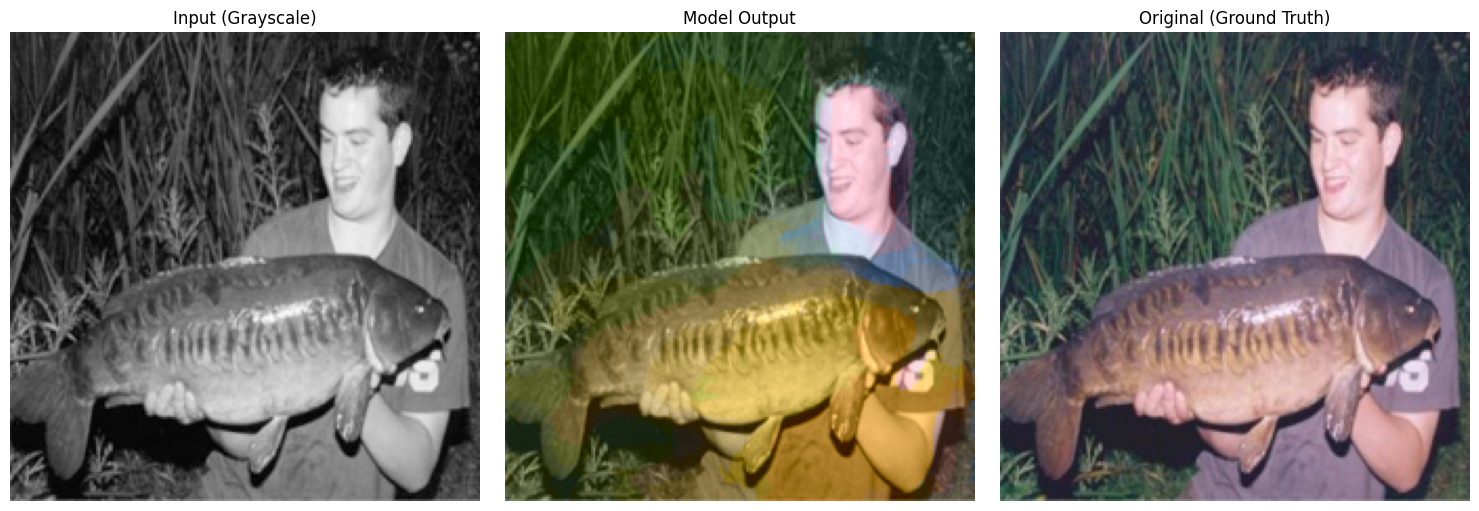

In [12]:
def colorize_imagenette_sample(epoch: int, image_index=0):
    model_path = os.path.join(
        OUT_DIR, "model", f"colorization_model_imagenette_epoch_{epoch}.pth"
    )

    # 1. Initialize and load the model
    model = ColorfulImageColorizationNet().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # 2. Load the Imagenette dataset (we use the validation set)
    # If not already downloaded, download=True will fetch it into './data'
    val_dataset = torchvision.datasets.Imagenette(
        root=DATASET_DIR,
        split="val",
        download=True,
    )

    # Extract the image and ignore the classification label
    img_pil, _ = val_dataset[image_index]

    # 3. Image preprocessing
    img_resized = img_pil.convert("RGB").resize((224, 224))
    img_np = np.array(img_resized)

    # Convert to LAB and extract the L channel
    img_lab = skimage.color.rgb2lab(img_np)
    L_channel = img_lab[:, :, 0]

    # Prepare the tensor (N, C, H, W)
    # Remember: apply the same normalization used in your PrecomputedColorizationDataset
    L_tensor = (
        torch.Tensor(L_channel).unsqueeze(0).unsqueeze(0).to(device) / 100.0
    )  # Normalize L to [0.0, 1.0]

    # 4. Forward Pass (Inference)
    with torch.no_grad():
        outputs = model(L_tensor)

    # 5. Postprocessing
    # Extract predicted indices and map them to 'ab' values
    pred_indices = torch.argmax(outputs, dim=1).squeeze().cpu().numpy()
    pred_ab = centroids[pred_indices]
    pred_ab = pred_ab * 256.0 - 128.0  # Denormalize a-b

    # Reconstruct the image
    out_lab = np.zeros((224, 224, 3))
    out_lab[:, :, 0] = L_channel
    out_lab[:, :, 1:] = pred_ab

    # Convert to RGB
    out_rgb = skimage.color.lab2rgb(out_lab)

    # 6. Three-panel visualization
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Panel 1: Input (Grayscale)
    ax[0].imshow(L_channel, cmap="gray")
    ax[0].set_title("Input (Grayscale)")
    ax[0].axis("off")

    # Panel 2: Model Output
    ax[1].imshow(out_rgb)
    ax[1].set_title("Model Output")
    ax[1].axis("off")

    # Panel 3: Original (Ground Truth)
    ax[2].imshow(img_np)
    ax[2].set_title("Original (Ground Truth)")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


colorize_imagenette_sample(
    epoch=20,
    image_index=29,  # Change this number to test other images (e.g., 10, 42, 100)
)